In [ ]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

In [ ]:
# Cargar datos GTFS
stop_times = pd.read_csv("stop_times.txt")
stops = pd.read_csv("stops.txt")

In [ ]:
 #Seleccionar un trip_id concreto
trip_id = "302_I_D_0700"   # reemplaza con el trip_id que quieras analizar
stop_times_trip = stop_times[stop_times["trip_id"] == trip_id].sort_values("stop_sequence")

In [ ]:
# Crear grafo dirigido
G = nx.DiGraph()

In [ ]:
# Añadir nodos (solo las paradas de ese trip)
for _, row in stops[stops["stop_id"].isin(stop_times_trip["stop_id"])].iterrows():
    G.add_node(row["stop_id"], name=row["stop_name"],
               pos=(row["stop_lon"], row["stop_lat"]))

In [ ]:
# Añadir aristas (segmentos consecutivos de ese trip)
for i in range(len(stop_times_trip)-1):
    u = stop_times_trip.iloc[i]["stop_id"]
    v = stop_times_trip.iloc[i+1]["stop_id"]
    dist = stop_times_trip.iloc[i]["dist_to_next_m"] if "dist_to_next_m" in stop_times_trip.columns else None
    G.add_edge(u, v, trip=trip_id, distance=dist)

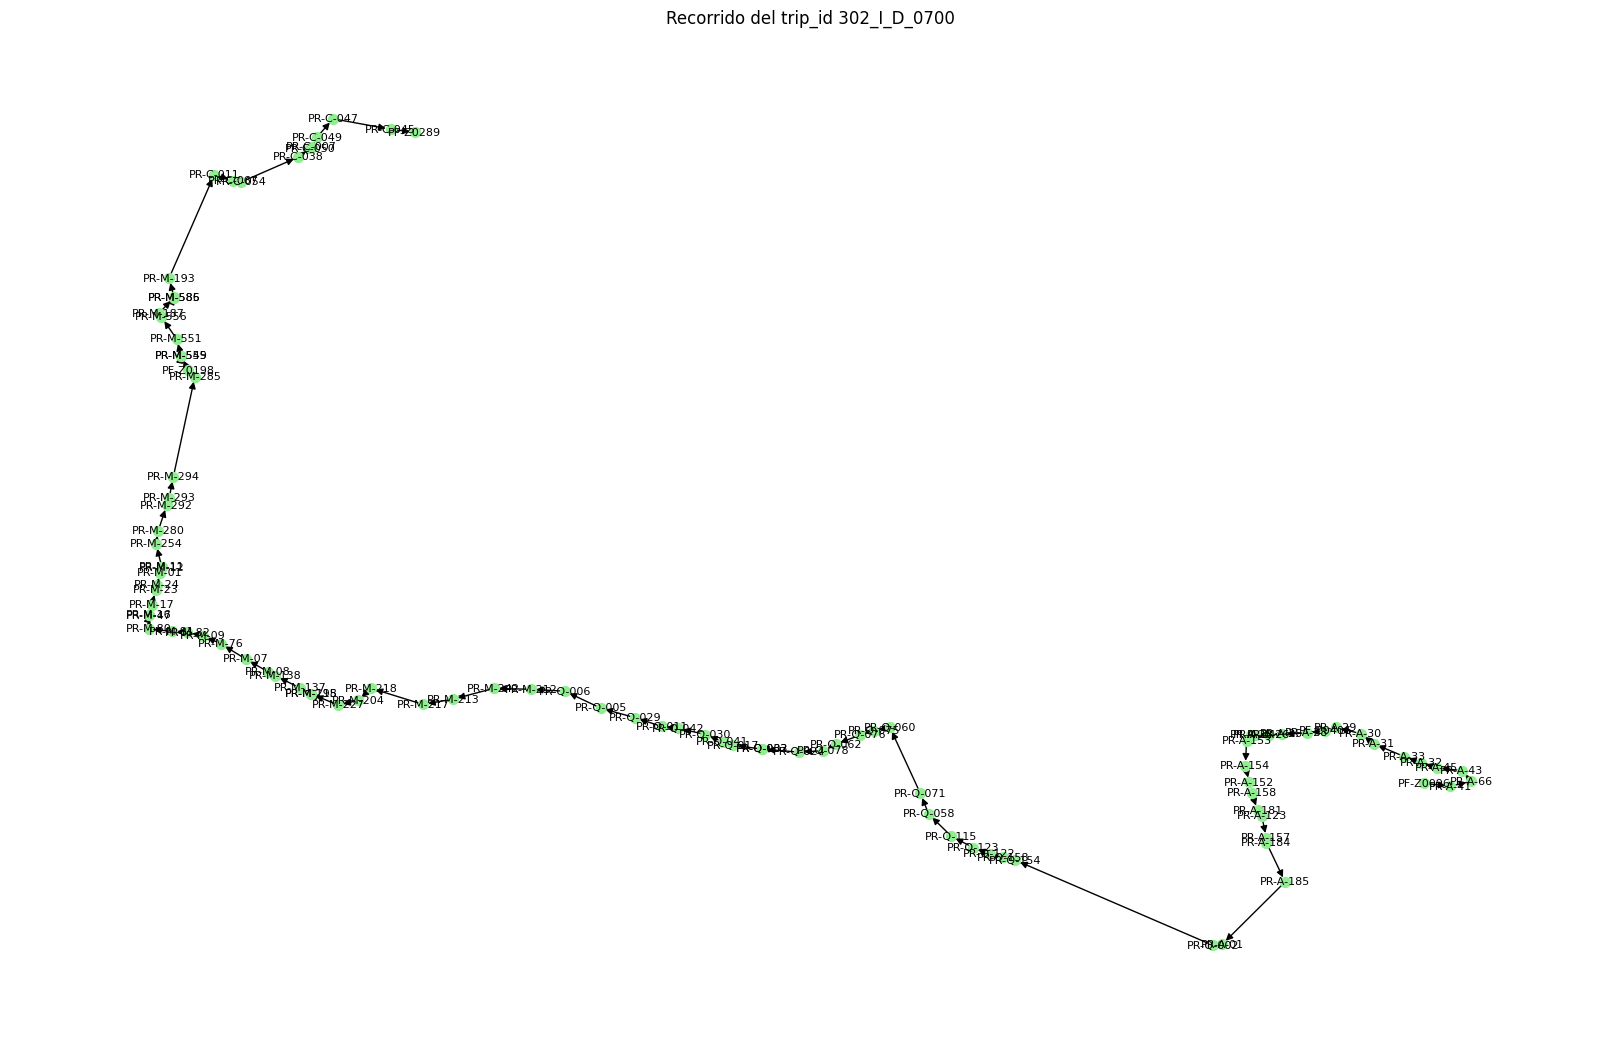

In [ ]:
# Dibujar grafo
pos = nx.get_node_attributes(G, "pos")
plt.figure(figsize=(16, 10)) #(ancho,largo)
nx.draw(G, pos, with_labels=True,
        node_size=50, node_color="lightgreen",#
        font_size=8, arrows=True)
plt.title(f"Recorrido del trip_id {trip_id}")
plt.show()
